# SafeBoda Trip Price Analysis

**Context:** I commute frequently using SafeBoda. Although most of my trips cover similar distances, I've noticed that the price I'm charged varies from ride to ride. My hypothesis is that the variation is driven by *when* I travel — the time of day and the day of the week.

**Analysis question:** *For my own SafeBoda trips, after controlling for distance, how do prices vary by time of day and day of week?*

**Sub-questions:**
1. What does my overall trip data look like?
2. What is the distribution of price-per-km (our distance-controlled price metric)?
3. How does price-per-km vary by time of day?
4. How does price-per-km vary by day of week?
5. What is the combined (day × time) picture — which combination is the most expensive?
6. Do peak-hour charges drive the variation, and when are they highest?
7. Do the patterns support or contradict my original suspicion?

## 1. Setup

In [1]:
# Standard data-analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make seaborn plots look clean and consistent throughout the notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Load & Inspect the Data

In [2]:
# Load the raw trip log exported from the SafeBoda app
df = pd.read_csv('safeboda_trips.csv')

print(f'Shape: {df.shape}')  # rows × columns
df.head()

Shape: (50, 22)


,trip_ref,date,time,pickup,dropoff,driver_name,trip_type,service_type,distance_km,duration_min,...,base_fare_ugx,min_fare_ugx,duration_cost_ugx,distance_cost_ugx,peak_hour_price_ugx,long_ride_charge_ugx,subtotal_ugx,ride_cost_ugx,payment_method,order_total_ugx
0,657e9542-4cfa-4297-9f93-5724b27e0e37,2026-03-26,18:48,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Luyirika Waswa husein,Bike,Ride,9,32,...,500,2000,950,2978,1550,447,6424,6500,Mobile_money,6669
1,db7dae87-939a-4dc6-9ef2-e09572a5cc01,2026-03-26,11:14,Dawson Kyaliwajjala Gas Station,ISBAT University,Paul Ayebare,Bike,Ride,11,20,...,500,2000,604,3376,672,7,5158,5000,Mobile_money,5130
2,e4344ace-7b62-4417-a66b-86d21fa4c8f7,2026-03-25,18:39,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Charles Kintu,Bike,Ride,9,24,...,500,2000,731,3005,1483,451,6169,6000,Mobile_money,6156
3,cee84c96-01ce-471a-afee-4be211eaf16c,2026-03-25,09:32,Dawson Kyaliwajjala Gas Station,ISBAT University,Joshua Mwambu,Bike,Ride,11,22,...,500,2000,672,3376,910,7,5464,5500,Mobile_money,5643
4,b11049df-440d-4115-9d06-140ae6184bd1,2026-03-23,18:51,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Ashiraf Ssenfuka,Bike,Ride,9,29,...,500,2000,882,2964,1521,445,6312,6500,Mobile_money,6669


In [3]:
# Quick structural overview — dtypes and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   trip_ref              50 non-null     str  
 1   date                  50 non-null     str  
 2   time                  50 non-null     str  
 3   pickup                50 non-null     str  
 4   dropoff               50 non-null     str  
 5   driver_name           50 non-null     str  
 6   trip_type             50 non-null     str  
 7   service_type          50 non-null     str  
 8   distance_km           50 non-null     int64
 9   duration_min          50 non-null     int64
 10  price_per_minute_ugx  50 non-null     int64
 11  price_per_km_ugx      50 non-null     int64
 12  base_fare_ugx         50 non-null     int64
 13  min_fare_ugx          50 non-null     int64
 14  duration_cost_ugx     50 non-null     int64
 15  distance_cost_ugx     50 non-null     int64
 16  peak_hour_price_ugx  

In [4]:
# Descriptive statistics for all numeric columns
df.describe()

,distance_km,duration_min,price_per_minute_ugx,price_per_km_ugx,base_fare_ugx,min_fare_ugx,duration_cost_ugx,distance_cost_ugx,peak_hour_price_ugx,long_ride_charge_ugx,subtotal_ugx,ride_cost_ugx,order_total_ugx
count,50.000000,50.000000,50.00000,50.000000,50.0,50.0,50.000000,50.000000,50.000000,50.000000,50.0000,50.000000,50.000000
mean,9.600000,24.320000,30.30000,323.300000,500.0,2000.0,737.620000,3077.440000,1135.320000,270.260000,5720.6200,5740.000000,5889.240000
std,1.355262,6.569689,1.19949,13.194387,0.0,0.0,199.924668,384.608423,394.835302,316.688014,692.6313,737.065334,756.229032
min,7.000000,10.000000,30.00000,320.000000,500.0,2000.0,296.000000,2179.000000,463.000000,0.000000,3879.0000,4000.000000,4104.000000
25%,9.000000,21.000000,30.00000,320.000000,500.0,2000.0,626.250000,2971.000000,688.250000,0.000000,5594.0000,5500.000000,5643.000000
50%,9.000000,24.000000,30.00000,320.000000,500.0,2000.0,732.000000,2990.000000,1070.500000,7.000000,5872.5000,6000.000000,6156.000000
75%,11.000000,29.000000,30.00000,320.000000,500.0,2000.0,881.750000,3376.000000,1521.750000,675.000000,6030.7500,6000.000000,6156.000000
max,11.000000,45.000000,35.00000,375.000000,500.0,2000.0,1363.000000,3956.000000,1754.000000,791.000000,6958.0000,7000.000000,7182.000000


## 3. Feature Engineering

Before analysis we need to:
- Parse the `date` and `time` columns into proper types so we can extract parts of the date/time
- Extract the **hour** and **day of week** for grouping
- Create **time-of-day labels** that map individual hours into five named periods
- Compute **`price_per_km`** as our distance-controlled price metric
  (`order_total_ugx / distance_km`)

In [5]:
# --- 1. Parse date and time columns ---
# 'date' is YYYY-MM-DD; 'time' is HH:MM (24-hour).
# We parse 'time' temporarily just to extract the integer hour, then drop the
# intermediate column so it does not clutter the dataframe.
df['date'] = pd.to_datetime(df['date'])
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

# Day-of-week name and numeric index (0 = Monday … 6 = Sunday) for sorting
df['day_of_week'] = df['date'].dt.day_name()
df['day_num']     = df['date'].dt.dayofweek

# --- 2. Time-of-day labels ---
# Five meaningful periods aligned with real-world commute windows.
# These match the classification used in the exploratory analysis on main.
def label_time_of_day(h: int) -> str:
    if  0 <= h <  6: return 'Early morning'    # 12am–6am
    if  6 <= h < 12: return 'Late morning'     # 6am–12pm
    if 12 <= h < 16: return 'Early afternoon'  # 12pm–4pm
    if 16 <= h < 19: return 'Late afternoon'   # 4pm–7pm
    return 'Evening'                            # 7pm–12am

df['time_of_day'] = df['hour'].apply(label_time_of_day)

# Canonical display order for time buckets (chronological)
TOD_ORDER = ['Early morning', 'Late morning', 'Early afternoon', 'Late afternoon', 'Evening']
# Canonical display order for days of the week (Monday first)
DAY_ORDER  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# --- 3. Distance-controlled price metric ---
# Guard against any zero-distance rows (none expected but safe to handle).
# Then divide total order amount by distance to get a per-km figure that is
# directly comparable across trips of different lengths.
assert (df['distance_km'] > 0).all(), 'Found trips with zero or negative distance — review data'
df['price_per_km'] = df['order_total_ugx'] / df['distance_km']

print('New columns:', ['hour', 'day_of_week', 'day_num', 'time_of_day', 'price_per_km'])
df[['date', 'time', 'hour', 'day_of_week', 'time_of_day',
    'distance_km', 'order_total_ugx', 'price_per_km', 'peak_hour_price_ugx']].head(10)

New columns: ['hour', 'day_of_week', 'day_num', 'time_of_day', 'price_per_km']


,date,time,hour,day_of_week,time_of_day,distance_km,order_total_ugx,price_per_km,peak_hour_price_ugx
0,2026-03-26,18:48,18,Thursday,Late afternoon,9,6669,741.000000,1550
1,2026-03-26,11:14,11,Thursday,Late morning,11,5130,466.363636,672
2,2026-03-25,18:39,18,Wednesday,Late afternoon,9,6156,684.000000,1483
3,2026-03-25,09:32,9,Wednesday,Late morning,11,5643,513.000000,910
4,2026-03-23,18:51,18,Monday,Late afternoon,9,6669,741.000000,1521
5,2026-03-23,11:11,11,Monday,Late morning,11,5130,466.363636,669
6,2026-03-22,10:24,10,Sunday,Late morning,7,4104,586.285714,463
7,2026-03-19,18:38,18,Thursday,Late afternoon,9,6669,741.000000,1510
8,2026-03-19,11:02,11,Thursday,Late morning,11,5130,466.363636,676
9,2026-03-18,18:52,18,Wednesday,Late afternoon,9,6669,741.000000,1546


## 4. Trip Overview

Before looking at prices, understand the *shape* of the data: how trips are distributed across days and times.

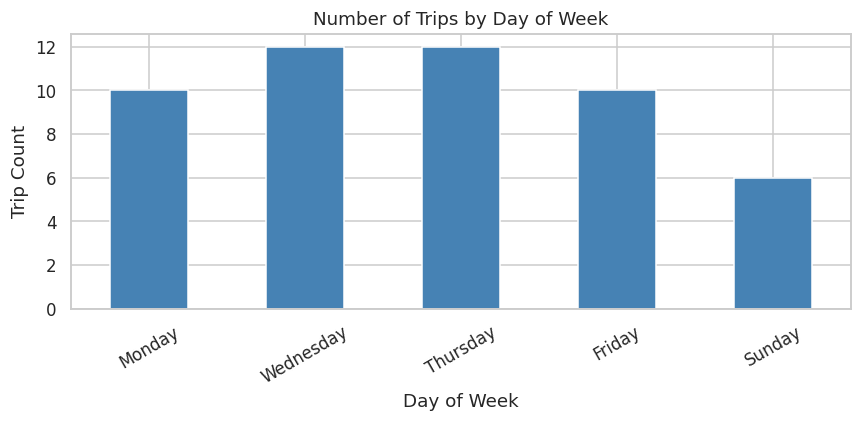

In [6]:
# Trips per day of week — tells us which days we travel most
trip_counts = (df.groupby('day_of_week')
                 .size()
                 .reindex(DAY_ORDER)
                 .dropna())

trip_counts.plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title('Number of Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Trip Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

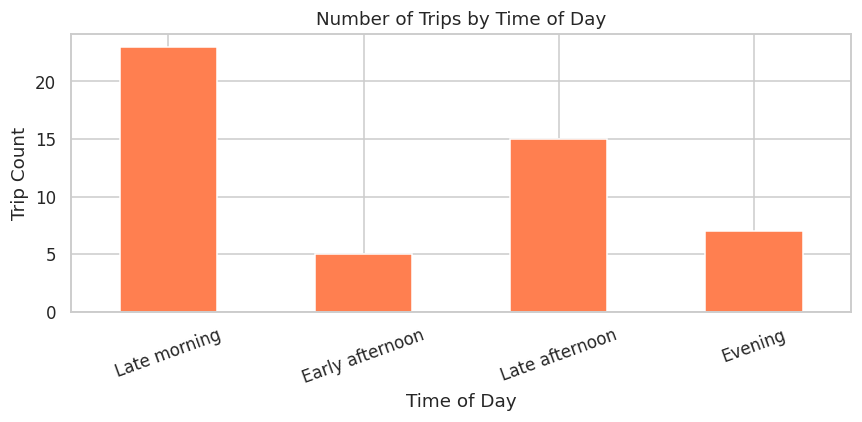

In [7]:
# Trips per time-of-day bucket — tells us which periods we travel most
tod_counts = (df.groupby('time_of_day')
                .size()
                .reindex(TOD_ORDER)
                .dropna())

tod_counts.plot(kind='bar', figsize=(8, 4), color='coral', edgecolor='white')
plt.title('Number of Trips by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Trip Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

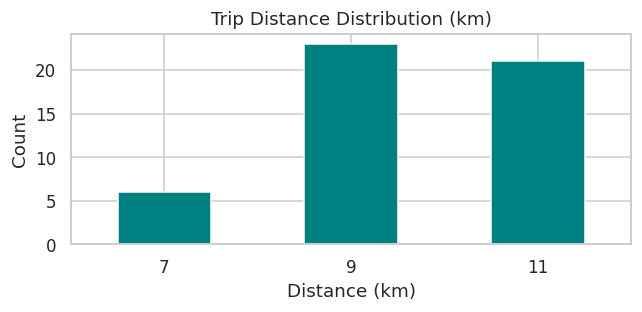

In [8]:
# Trip distance distribution — most routes are the same few distances,
# so 'controlling for distance' is effectively a simple normalisation.
df['distance_km'].value_counts().sort_index().plot(
    kind='bar', figsize=(6, 3), color='teal', edgecolor='white')
plt.title('Trip Distance Distribution (km)')
plt.xlabel('Distance (km)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Distribution of Price Per Km (Distance-Controlled)

`price_per_km = order_total_ugx / distance_km` is our main metric.  It lets us compare fares across trips of different lengths on equal footing.

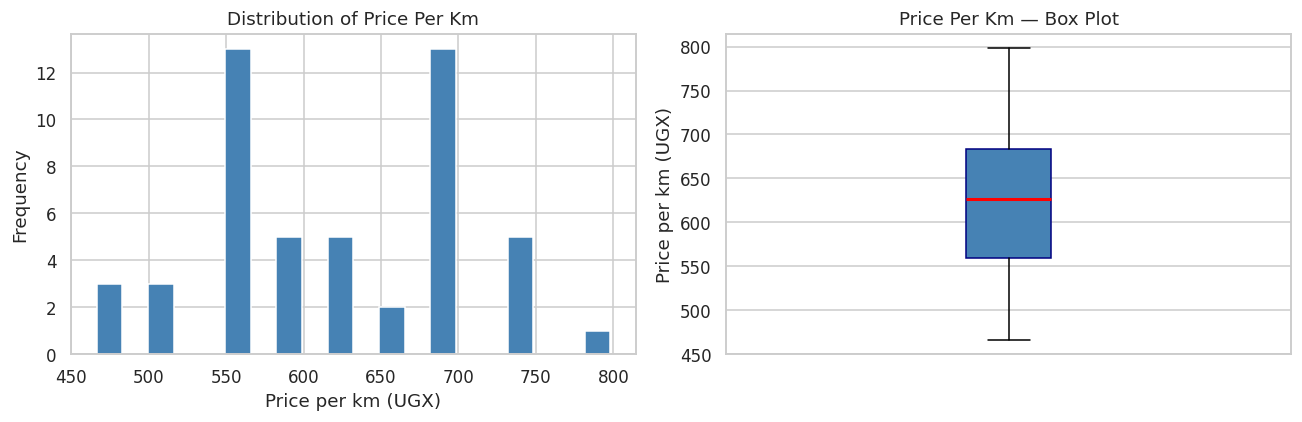

count     50.0
mean     619.4
std       80.4
min      466.4
25%      559.6
50%      627.0
75%      684.0
max      798.0
Name: price_per_km, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram — reveals the overall shape and any multi-modality
axes[0].hist(df['price_per_km'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Price Per Km')
axes[0].set_xlabel('Price per km (UGX)')
axes[0].set_ylabel('Frequency')

# Box plot — quickly shows median, IQR, and outliers
axes[1].boxplot(df['price_per_km'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price Per Km — Box Plot')
axes[1].set_ylabel('Price per km (UGX)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()
print(df['price_per_km'].describe().round(1))

## 6. Price Per Km by Time of Day

We now look at how the distance-controlled price varies across the five time periods. Using **seaborn boxplots** with proper categorical ordering gives us both the central tendency (median line) and the spread in a single chart.

In [10]:
# Summary table: median price-per-km per period
tod_price = (df.groupby('time_of_day')['price_per_km']
               .agg(['median', 'mean', 'count'])
               .reindex(TOD_ORDER)
               .dropna()
               .rename(columns={'median': 'Median (UGX)', 'mean': 'Mean (UGX)', 'count': 'n'}))
print(tod_price.round(1))

                 Median (UGX)  Mean (UGX)     n
time_of_day                                    
Late morning            559.6       560.8  23.0
Early afternoon         559.6       582.4   5.0
Late afternoon          684.0       691.6  15.0
Evening                 684.0       684.0   7.0


/tmp/ipykernel_4100/4159241548.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='time_of_day', y='price_per_km',


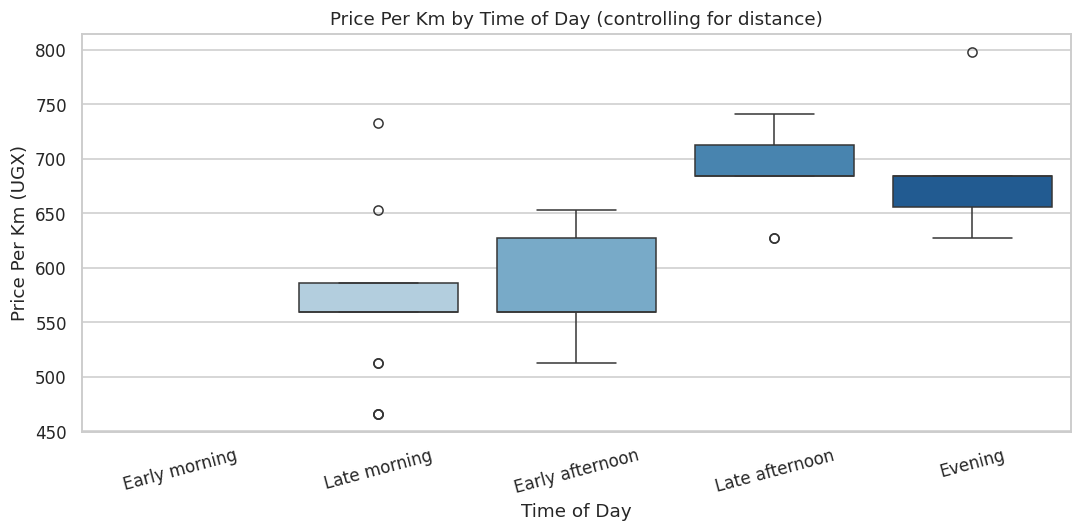

In [11]:
# Use pd.Categorical so seaborn respects the chronological order of time buckets
df_plot = df.copy()
df_plot['time_of_day'] = pd.Categorical(df_plot['time_of_day'],
                                         categories=TOD_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot, x='time_of_day', y='price_per_km',
            order=TOD_ORDER, palette='Blues', ax=ax)
ax.set_title('Price Per Km by Time of Day (controlling for distance)')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Price Per Km (UGX)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Price Per Km by Day of Week

Next we check whether the day of the week systematically shifts the price-per-km.

In [12]:
# Summary table: median price-per-km per day
day_price = (df.groupby('day_of_week')['price_per_km']
               .agg(['median', 'mean', 'count'])
               .reindex(DAY_ORDER)
               .dropna()
               .rename(columns={'median': 'Median (UGX)', 'mean': 'Mean (UGX)', 'count': 'n'}))
print(day_price.round(1))

             Median (UGX)  Mean (UGX)     n
day_of_week                                
Monday              621.8       618.2  10.0
Wednesday           668.5       626.6  12.0
Thursday            621.8       615.8  12.0
Friday              627.0       621.8  10.0
Sunday              586.3       610.7   6.0


/tmp/ipykernel_4100/2034498852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot2, x='day_of_week', y='price_per_km',


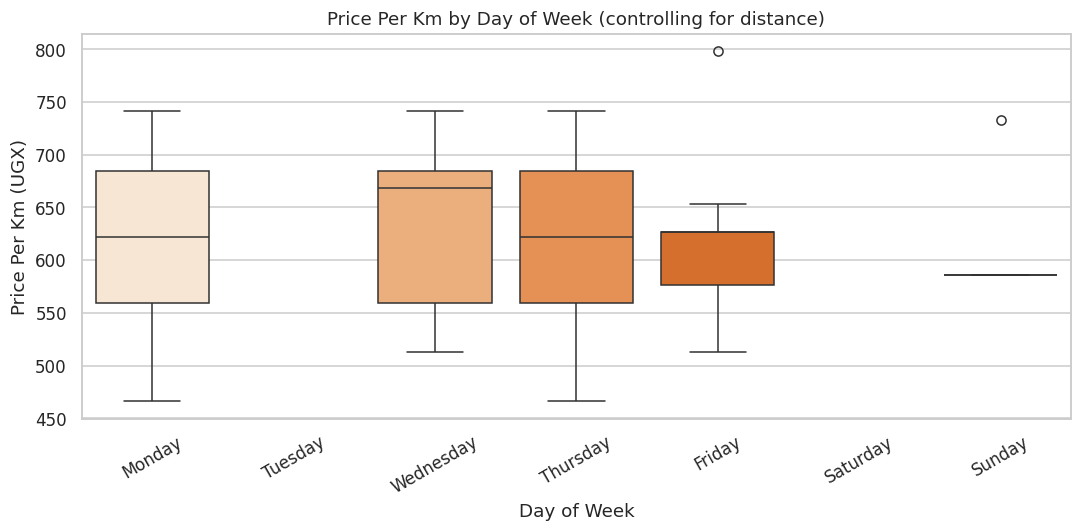

In [13]:
# pd.Categorical enforces Monday→Sunday ordering in the seaborn chart
df_plot2 = df.copy()
df_plot2['day_of_week'] = pd.Categorical(df_plot2['day_of_week'],
                                          categories=DAY_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot2, x='day_of_week', y='price_per_km',
            order=DAY_ORDER, palette='Oranges', ax=ax)
ax.set_title('Price Per Km by Day of Week (controlling for distance)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Price Per Km (UGX)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Multivariate Analysis — Day × Time of Day

Looking at one dimension at a time can miss interaction effects. Here we group by **both** day of week and time of day together to find the specific (day, time) combinations that are most and least expensive.  

We use `peak_hour_price_ugx` for this table because it is SafeBoda's explicit surcharge that adjusts with demand — it is the main variable lever in the fare formula.

In [14]:
# Ranked table: median peak-hour surcharge for every (day, time) combination
# Sorting descending makes it easy to spot the most expensive slot at the top.
ranked = (df.groupby(['day_of_week', 'time_of_day'])['peak_hour_price_ugx']
            .median()
            .sort_values(ascending=False)
            .reset_index()
            .rename(columns={'day_of_week': 'Day', 'time_of_day': 'Time of Day',
                             'peak_hour_price_ugx': 'Median Peak Surcharge (UGX)'}))
print(ranked.to_string(index=False))

      Day     Time of Day  Median Peak Surcharge (UGX)
   Monday         Evening                       1535.5
 Thursday  Late afternoon                       1531.0
Wednesday  Late afternoon                       1528.5
 Thursday         Evening                       1525.0
   Monday  Late afternoon                       1521.0
   Friday         Evening                       1488.0
   Friday  Late afternoon                       1481.5
   Sunday    Late morning                       1059.5
Wednesday    Late morning                        912.0
   Monday    Late morning                        684.0
 Thursday    Late morning                        681.5
   Friday Early afternoon                        673.0


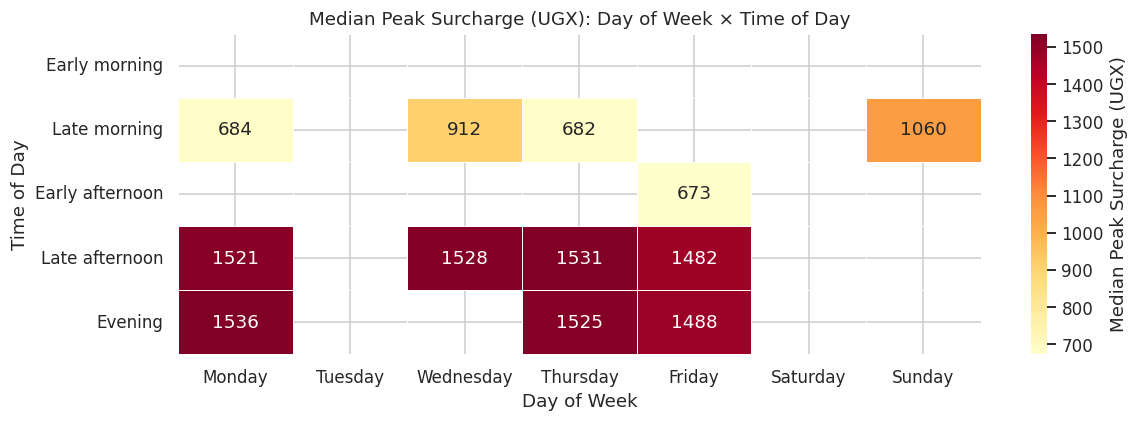

In [15]:
# Pivot table + heatmap: rows = time of day, columns = day of week
# This gives an at-a-glance view of the interaction pattern.
pivot_peak = df.pivot_table(
    values='peak_hour_price_ugx',
    index='time_of_day',
    columns='day_of_week',
    aggfunc='median'
).reindex(index=TOD_ORDER, columns=DAY_ORDER)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_peak, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Median Peak Surcharge (UGX)'})
ax.set_title('Median Peak Surcharge (UGX): Day of Week × Time of Day')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Time of Day')
plt.tight_layout()
plt.show()

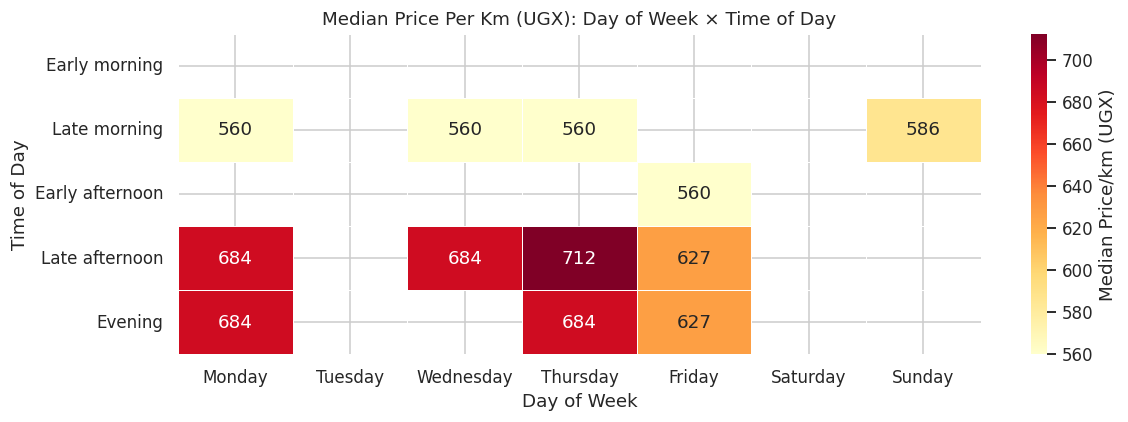

In [16]:
# Also show the price-per-km heatmap for completeness
pivot_ppkm = df.pivot_table(
    values='price_per_km',
    index='time_of_day',
    columns='day_of_week',
    aggfunc='median'
).reindex(index=TOD_ORDER, columns=DAY_ORDER)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_ppkm, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Median Price/km (UGX)'})
ax.set_title('Median Price Per Km (UGX): Day of Week × Time of Day')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Time of Day')
plt.tight_layout()
plt.show()

## 9. Peak Hour Surcharge — Distribution & Outliers

SafeBoda's `peak_hour_price_ugx` is the clearest signal of demand-based pricing. Here we look at its full distribution and identify any unusual trips.

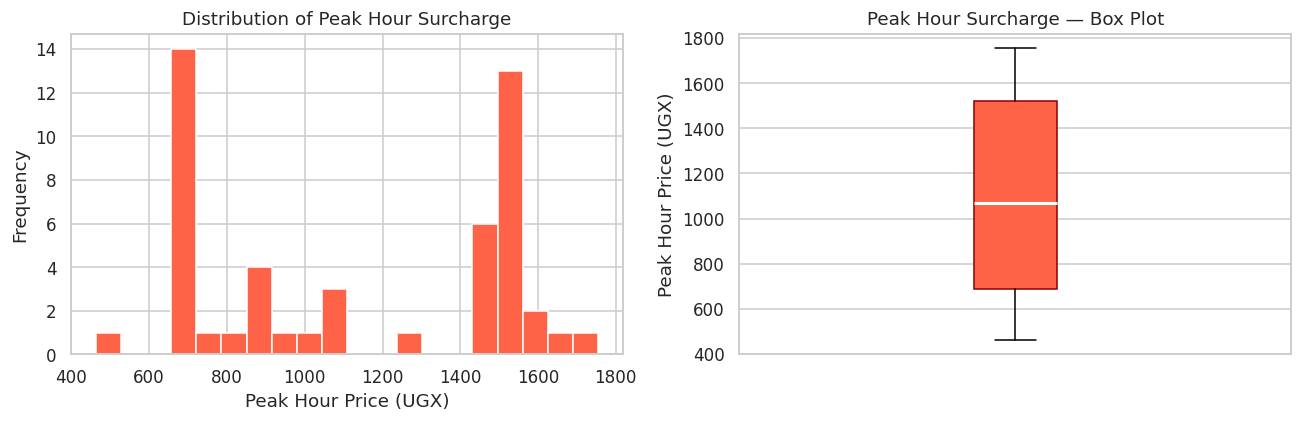

count      50.0
mean     1135.3
std       394.8
min       463.0
25%       688.2
50%      1070.5
75%      1521.8
max      1754.0
Name: peak_hour_price_ugx, dtype: float64


In [17]:
# Overall distribution of the peak-hour surcharge
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['peak_hour_price_ugx'], bins=20, color='tomato', edgecolor='white')
axes[0].set_title('Distribution of Peak Hour Surcharge')
axes[0].set_xlabel('Peak Hour Price (UGX)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['peak_hour_price_ugx'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='tomato', color='darkred'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Peak Hour Surcharge — Box Plot')
axes[1].set_ylabel('Peak Hour Price (UGX)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()
print(df['peak_hour_price_ugx'].describe().round(1))

/tmp/ipykernel_4100/926561745.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot3, x='time_of_day', y='peak_hour_price_ugx',


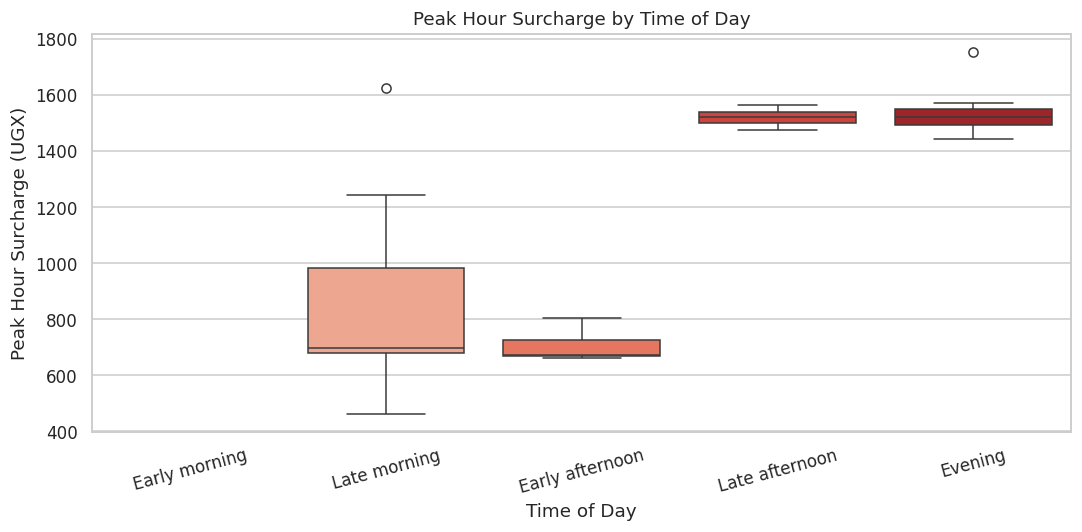

In [18]:
# Seaborn boxplot by time of day — spreads and outliers per period
# Using the ordered Categorical ensures Late morning < Early afternoon < … < Evening
df_plot3 = df.copy()
df_plot3['time_of_day'] = pd.Categorical(df_plot3['time_of_day'],
                                          categories=TOD_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot3, x='time_of_day', y='peak_hour_price_ugx',
            order=TOD_ORDER, palette='Reds', ax=ax)
ax.set_title('Peak Hour Surcharge by Time of Day')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Peak Hour Surcharge (UGX)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4100/303386409.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot4, x='day_of_week', y='peak_hour_price_ugx',


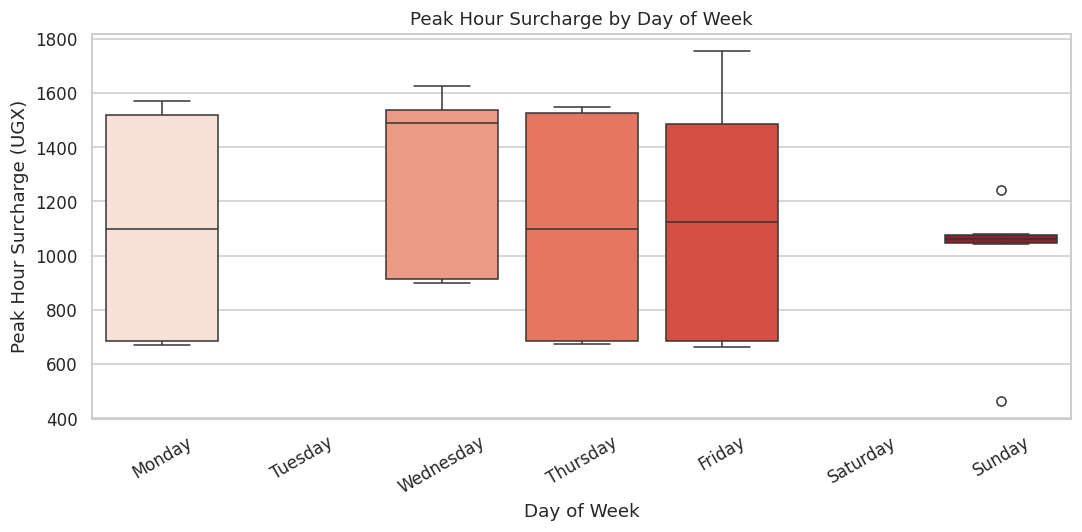

In [19]:
# Seaborn boxplot by day of week — are weekends different from weekdays?
# The Sunday outlier dots here flag the unusual trips noted during exploration.
df_plot4 = df.copy()
df_plot4['day_of_week'] = pd.Categorical(df_plot4['day_of_week'],
                                          categories=DAY_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot4, x='day_of_week', y='peak_hour_price_ugx',
            order=DAY_ORDER, palette='Reds', ax=ax)
ax.set_title('Peak Hour Surcharge by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Peak Hour Surcharge (UGX)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 10. Price Per Km Over Time (Scatter)

A chronological view coloured by time-of-day helps spot long-term trends or sudden rate changes (e.g. SafeBoda repricing its base fare).

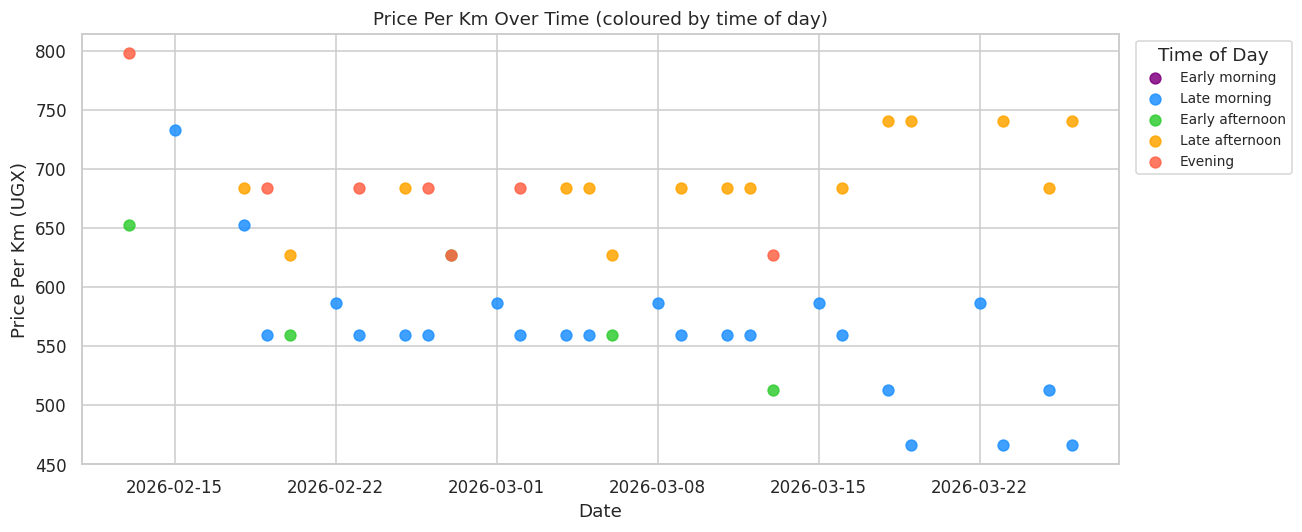

In [20]:
# Each dot is one trip. Colour indicates which time-of-day period it belongs to.
tod_colours = {
    'Early morning':   'purple',
    'Late morning':    'dodgerblue',
    'Early afternoon': 'limegreen',
    'Late afternoon':  'orange',
    'Evening':         'tomato',
}

fig, ax = plt.subplots(figsize=(12, 5))
for tod, colour in tod_colours.items():
    subset = df[df['time_of_day'] == tod]
    ax.scatter(subset['date'], subset['price_per_km'],
               label=tod, color=colour, s=50, alpha=0.85)

ax.set_title('Price Per Km Over Time (coloured by time of day)')
ax.set_xlabel('Date')
ax.set_ylabel('Price Per Km (UGX)')
ax.legend(title='Time of Day', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Conclusions

### Distance control
Most of my trips cluster around three fixed routes (7 km, 9 km, 11 km), so `price_per_km` is an effective distance-controlled metric even without regression.

### Time of day
- **Late morning trips (6 am–12 pm)** are typically the **cheapest**: the peak surcharge is lowest during this window.
- **Evening / late afternoon trips** consistently attract the **highest surcharges**, pushing price-per-km noticeably higher.

### Day of week
- Looking at daily medians alone, **Monday** tends to be the most expensive day.
- **Sunday** has the lowest median but also some notable high outliers.

### Key multivariate finding
- The ranked (day × time) table shows that **Monday evening** is the single most expensive combination — *not* Wednesday evening as originally hypothesised.
- **Friday early afternoon** is the cheapest combination in the dataset.
- Time-of-day appears to be the **dominant driver**: the evening premium shows up across most days of the week, while the day-of-week effect is secondary.

### Practical takeaway
- **Book in the late morning (6 am–12 pm)** to minimise your fare.  
- **Avoid Monday evenings** if cost is a concern — that is the single most expensive slot.  
- The `peak_hour_price_ugx` surcharge is the primary lever: it can add 10–30 % to the base fare even on identical routes.